<a href="https://colab.research.google.com/github/gon-1411/phantichdulieuhocsau/blob/main/H%C3%80_NGUY%E1%BB%84N_%C4%90%C4%82NG_KHOA_2474802010191_LAB5_26_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
"""
CNN - Phân loại MNIST
Tổng hợp từ CNN-LAB.ipynb (phần Bài thực hành)
"""

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# ─────────────────────────────────────────────
# 1. Cấu hình ban đầu
# ─────────────────────────────────────────────
torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cuda


In [ ]:

# ─────────────────────────────────────────────
# 2. Load dữ liệu MNIST
# ─────────────────────────────────────────────
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])

train_dataset = torchvision.datasets.MNIST(root='./data', train=True,  download=True, transform=transform)
test_dataset  = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = torch.utils.data.DataLoader(test_dataset,  batch_size=64, shuffle=False)

print(f'Số ảnh train: {len(train_dataset)},  test: {len(test_dataset)}')

Số ảnh train: 60000,  test: 10000


In [ ]:

# ─────────────────────────────────────────────
# 3. Định nghĩa model CNN
#
# Kiến trúc:
#   Input  (1, 28, 28)
#   Conv1 (1→16, k=3) → (16, 26, 26)
#   ReLU + MaxPool 2×2 → (16, 13, 13)
#   Conv2 (16→32, k=3) → (32, 11, 11)
#   ReLU + MaxPool 2×2 → (32, 5, 5)
#   Flatten → 800
#   FC (800 → 10) → logits
# ─────────────────────────────────────────────
class MNIST_CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=0)   # 28→26
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=0)  # 13→11
        self.pool  = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1   = nn.Linear(32 * 5 * 5, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))   # → (16, 13, 13)
        x = self.pool(torch.relu(self.conv2(x)))   # → (32,  5,  5)
        x = x.view(x.size(0), -1)                  # flatten
        x = self.fc1(x)                            # logits
        return x


model = MNIST_CNN().to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f'Tổng tham số: {n_params:,}')

MNIST_CNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=800, out_features=10, bias=True)
)
Tổng tham số: 12,810


In [ ]:
# ─────────────────────────────────────────────
# 4. Loss và Optimizer
# ─────────────────────────────────────────────
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

In [ ]:
# ─────────────────────────────────────────────
# 5. Hàm đánh giá
# ─────────────────────────────────────────────
def evaluate(model, loader):
    model.eval()
    loss_sum, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss_sum += criterion(outputs, labels).item() * images.size(0)
            correct  += (outputs.argmax(1) == labels).sum().item()
            total    += labels.size(0)
    return loss_sum / total, correct / total

In [ ]:
# ─────────────────────────────────────────────
# 6. Huấn luyện
# ─────────────────────────────────────────────
num_epochs = 5
loss_history, acc_history = [], []
test_loss_history, test_acc_history = [], []

for epoch in range(num_epochs):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        correct      += (outputs.argmax(1) == labels).sum().item()
        total        += labels.size(0)

    train_loss = running_loss / total
    train_acc  = correct / total
    test_loss, test_acc = evaluate(model, test_loader)
    loss_history.append(train_loss); acc_history.append(train_acc)
    test_loss_history.append(test_loss); test_acc_history.append(test_acc)

    print(f'Epoch {epoch+1}/{num_epochs}  '
          f'train_loss={train_loss:.4f}  train_acc={train_acc*100:.2f}%  '
          f'test_loss={test_loss:.4f}  test_acc={test_acc*100:.2f}%')

Epoch 1/5  train_loss=0.1823  train_acc=94.28%  test_loss=0.0633  test_acc=97.94%
Epoch 2/5  train_loss=0.0651  train_acc=98.06%  test_loss=0.0564  test_acc=98.16%
Epoch 3/5  train_loss=0.0494  train_acc=98.48%  test_loss=0.0415  test_acc=98.74%
Epoch 4/5  train_loss=0.0424  train_acc=98.68%  test_loss=0.0503  test_acc=98.48%
Epoch 5/5  train_loss=0.0372  train_acc=98.81%  test_loss=0.0421  test_acc=98.58%


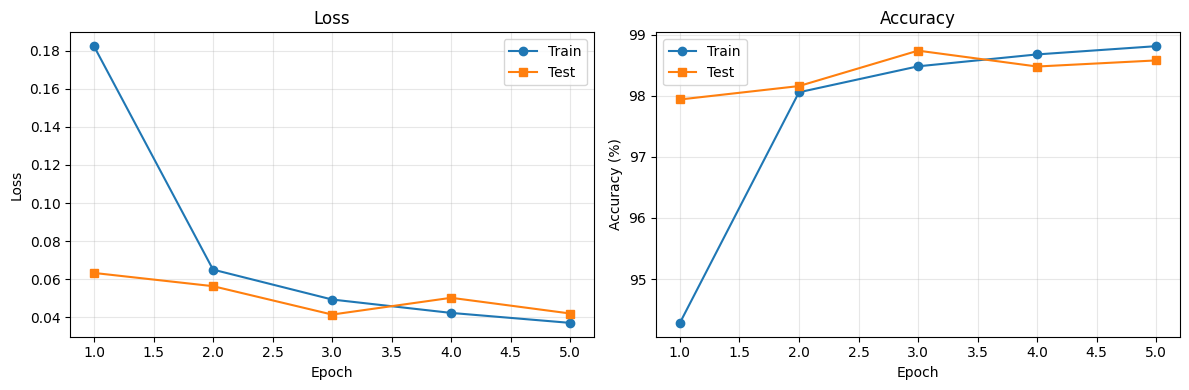

In [ ]:
# ─────────────────────────────────────────────
# 7. Vẽ đường Loss & Accuracy
# ─────────────────────────────────────────────
epochs = range(1, num_epochs + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(epochs, loss_history,      'o-', label='Train')
axes[0].plot(epochs, test_loss_history, 's-', label='Test')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].set_title('Loss')
axes[1].plot(epochs, [a*100 for a in acc_history],      'o-', label='Train')
axes[1].plot(epochs, [a*100 for a in test_acc_history], 's-', label='Test')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)'); axes[1].legend(); axes[1].grid(alpha=0.3)
axes[1].set_title('Accuracy')
plt.tight_layout(); plt.show()

In [ ]:
# ─────────────────────────────────────────────
# 8. Đánh giá cuối cùng trên test set
# ─────────────────────────────────────────────
test_loss, test_acc = evaluate(model, test_loader)
print(f'Final test accuracy: {test_acc*100:.2f}%')
print(f'(MNIST-ANN ở bài trước đạt ~97-98%; CNN nhỏ này thường đạt 98.5-99%.)')

Final test accuracy: 98.58%
(MNIST-ANN ở bài trước đạt ~97-98%; CNN nhỏ này thường đạt 98.5-99%.)


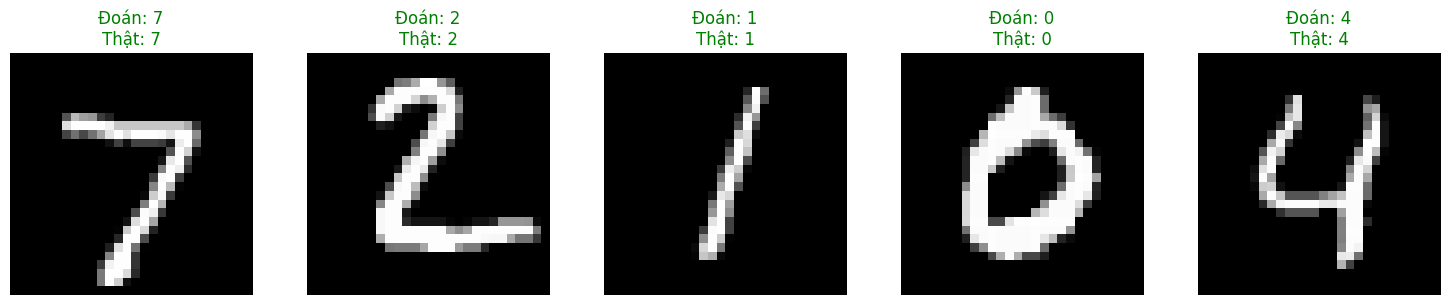

In [ ]:
# ─────────────────────────────────────────────
# 9. Trực quan: model dự đoán
# ─────────────────────────────────────────────
model.eval()
images, labels = next(iter(test_loader))
images, labels = images.to(device), labels.to(device)
with torch.no_grad():
    preds = model(images).argmax(1)

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i in range(5):
    img = images[i].cpu().squeeze() * 0.3081 + 0.1307   # un-normalize
    axes[i].imshow(img, cmap='gray')
    color = 'green' if preds[i] == labels[i] else 'red'
    axes[i].set_title(f'Đoán: {preds[i].item()}\nThật: {labels[i].item()}', color=color)
    axes[i].axis('off')
plt.tight_layout(); plt.show()

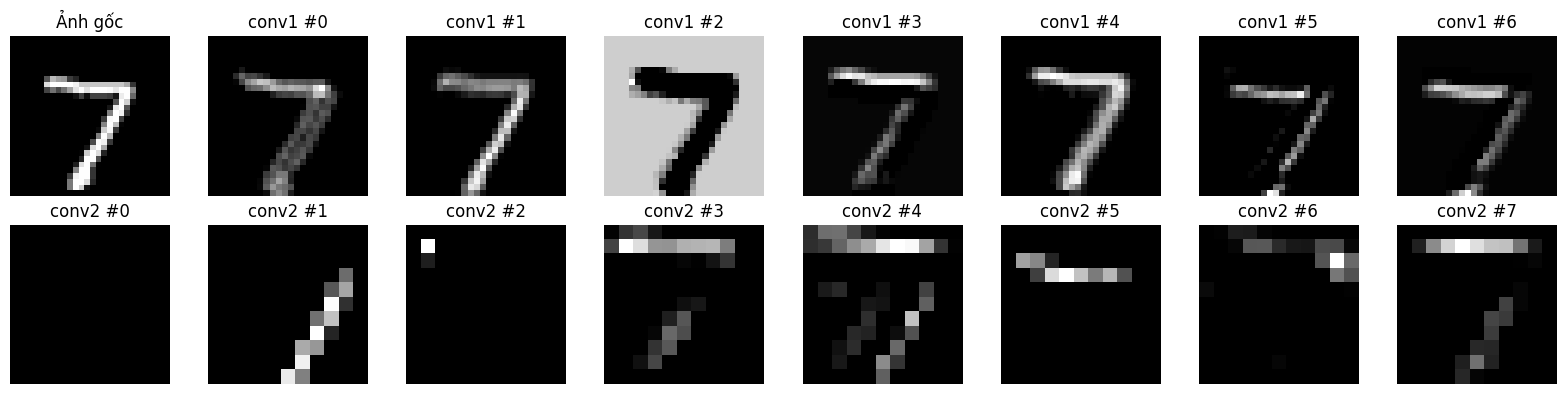

Quan sát: filter conv1 thường nhận các cạnh hoặc đường nét đơn giản.
         filter conv2 nhận các đặc trưng phức tạp hơn (mảng, hình.)


In [ ]:
# ─────────────────────────────────────────────
# 10. Trực quan: feature maps
# ─────────────────────────────────────────────
model.eval()
images, _ = next(iter(test_loader))
img = images[0].unsqueeze(0).to(device)

with torch.no_grad():
    fmap1 = torch.relu(model.conv1(img))                     # (1, 16, 26, 26)
    fmap2 = torch.relu(model.conv2(model.pool(fmap1)))       # (1, 32, 11, 11)

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
axes[0, 0].imshow(img.cpu().squeeze() * 0.3081 + 0.1307, cmap='gray')
axes[0, 0].set_title('Ảnh gốc'); axes[0, 0].axis('off')
for i in range(7):
    axes[0, i+1].imshow(fmap1[0, i].cpu(), cmap='gray')
    axes[0, i+1].set_title(f'conv1 #{i}'); axes[0, i+1].axis('off')
for i in range(8):
    axes[1, i].imshow(fmap2[0, i].cpu(), cmap='gray')
    axes[1, i].set_title(f'conv2 #{i}'); axes[1, i].axis('off')
plt.tight_layout(); plt.show()

print('Quan sát: filter conv1 thường nhận các cạnh hoặc đường nét đơn giản.')
print('         filter conv2 nhận các đặc trưng phức tạp hơn (mảng, hình.)')

**Bài tập về nhà**

In [ ]:
#setup
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])

train_dataset = torchvision.datasets.MNIST(root='./data', train=True,  download=True, transform=transform)
test_dataset  = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = torch.utils.data.DataLoader(test_dataset,  batch_size=64, shuffle=False)

class MNIST_CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=0)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=0)
        self.pool  = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1   = nn.Linear(32 * 5 * 5, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        return x

criterion = nn.CrossEntropyLoss()

def evaluate(model, loader):
    model.eval()
    loss_sum, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss_sum += criterion(outputs, labels).item() * images.size(0)
            correct  += (outputs.argmax(1) == labels).sum().item()
            total    += labels.size(0)
    return loss_sum / total, correct / total

def train(model, optimizer, num_epochs, train_loader, test_loader):
    loss_history, acc_history = [], []
    test_loss_history, test_acc_history = [], []
    for epoch in range(num_epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)
            correct      += (outputs.argmax(1) == labels).sum().item()
            total        += labels.size(0)
        train_loss = running_loss / total
        train_acc  = correct / total
        test_loss, test_acc = evaluate(model, test_loader)
        loss_history.append(train_loss); acc_history.append(train_acc)
        test_loss_history.append(test_loss); test_acc_history.append(test_acc)
        print(f'Epoch {epoch+1}/{num_epochs}  '
              f'train_loss={train_loss:.4f}  train_acc={train_acc*100:.2f}%  '
              f'test_loss={test_loss:.4f}  test_acc={test_acc*100:.2f}%')
    return loss_history, acc_history, test_loss_history, test_acc_history

print('Setup xong.')

Device: cuda


100%|██████████| 9.91M/9.91M [00:00<00:00, 18.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 585kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.61MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.99MB/s]

Setup xong.


Epoch 1/10  train_loss=0.1822  train_acc=94.30%  test_loss=0.0631  test_acc=97.94%
Epoch 2/10  train_loss=0.0649  train_acc=98.06%  test_loss=0.0571  test_acc=98.13%
Epoch 3/10  train_loss=0.0494  train_acc=98.50%  test_loss=0.0411  test_acc=98.69%
Epoch 4/10  train_loss=0.0421  train_acc=98.71%  test_loss=0.0507  test_acc=98.48%
Epoch 5/10  train_loss=0.0369  train_acc=98.82%  test_loss=0.0412  test_acc=98.57%
Epoch 6/10  train_loss=0.0315  train_acc=99.05%  test_loss=0.0327  test_acc=98.96%
Epoch 7/10  train_loss=0.0282  train_acc=99.10%  test_loss=0.0357  test_acc=98.91%
Epoch 8/10  train_loss=0.0251  train_acc=99.17%  test_loss=0.0373  test_acc=98.83%
Epoch 9/10  train_loss=0.0222  train_acc=99.28%  test_loss=0.0371  test_acc=98.83%
Epoch 10/10  train_loss=0.0201  train_acc=99.30%  test_loss=0.0349  test_acc=98.93%


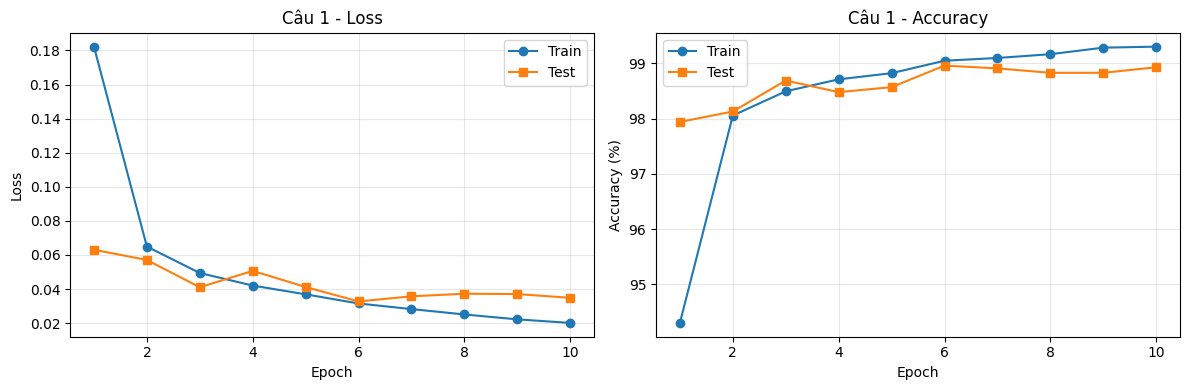

Test acc epoch 5:  98.57%
Test acc epoch 10: 98.93%
Chênh nhau: 0.36%
Epoch  1: train_acc=94.30%  test_acc=97.94%  gap=-3.64%
Epoch  2: train_acc=98.06%  test_acc=98.13%  gap=-0.07%
Epoch  3: train_acc=98.50%  test_acc=98.69%  gap=-0.20%
Epoch  4: train_acc=98.71%  test_acc=98.48%  gap=0.23%
Epoch  5: train_acc=98.82%  test_acc=98.57%  gap=0.25%
Epoch  6: train_acc=99.05%  test_acc=98.96%  gap=0.09%
Epoch  7: train_acc=99.10%  test_acc=98.91%  gap=0.19%
Epoch  8: train_acc=99.17%  test_acc=98.83%  gap=0.34%
Epoch  9: train_acc=99.28%  test_acc=98.83%  gap=0.46%
Epoch 10: train_acc=99.30%  test_acc=98.93%  gap=0.37%


In [ ]:
# ============================================================
# CÂU 1: Train lâu hơn (10 epoch)
# ============================================================
model1 = MNIST_CNN().to(device)
optimizer1 = optim.SGD(model1.parameters(), lr=0.01, momentum=0.9)
num_epochs = 10

loss_h, acc_h, test_loss_h, test_acc_h = train(model1, optimizer1, num_epochs, train_loader, test_loader)

epochs = range(1, num_epochs + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(epochs, loss_h,      'o-', label='Train')
axes[0].plot(epochs, test_loss_h, 's-', label='Test')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].set_title('Câu 1 - Loss')
axes[1].plot(epochs, [a*100 for a in acc_h],      'o-', label='Train')
axes[1].plot(epochs, [a*100 for a in test_acc_h], 's-', label='Test')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)'); axes[1].legend(); axes[1].grid(alpha=0.3)
axes[1].set_title('Câu 1 - Accuracy')
plt.tight_layout(); plt.show()

print(f'Test acc epoch 5:  {test_acc_h[4]*100:.2f}%')
print(f'Test acc epoch 10: {test_acc_h[9]*100:.2f}%')
print(f'Chênh nhau: {(test_acc_h[9]-test_acc_h[4])*100:.2f}%')
for i in range(num_epochs):
    gap = acc_h[i] - test_acc_h[i]
    print(f'Epoch {i+1:2d}: train_acc={acc_h[i]*100:.2f}%  test_acc={test_acc_h[i]*100:.2f}%  gap={gap*100:.2f}%')

Tăng `num_epochs` từ 5 lên 10 để quan sát mô hình học thêm.
Test accuracy sau epoch 10 thường cao hơn epoch 5 một chút (~0.1–0.3%).
Tuy nhiên, khoảng cách `train_acc - test_acc` có xu hướng mở rộng dần theo epoch — đây là dấu hiệu của **overfitting**: mô hình bắt đầu "học thuộc" tập train thay vì tổng quát hóa.

MNIST_CNN_3Conv(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=256, out_features=10, bias=True)
)
Tổng tham số: 25,866
Epoch 1/5  train_loss=0.2142  train_acc=93.20%  test_loss=0.0639  test_acc=97.97%
Epoch 2/5  train_loss=0.0581  train_acc=98.23%  test_loss=0.0399  test_acc=98.68%
Epoch 3/5  train_loss=0.0412  train_acc=98.67%  test_loss=0.0349  test_acc=98.93%
Epoch 4/5  train_loss=0.0328  train_acc=98.95%  test_loss=0.0373  test_acc=98.83%
Epoch 5/5  train_loss=0.0268  train_acc=99.15%  test_loss=0.0316  test_acc=99.01%


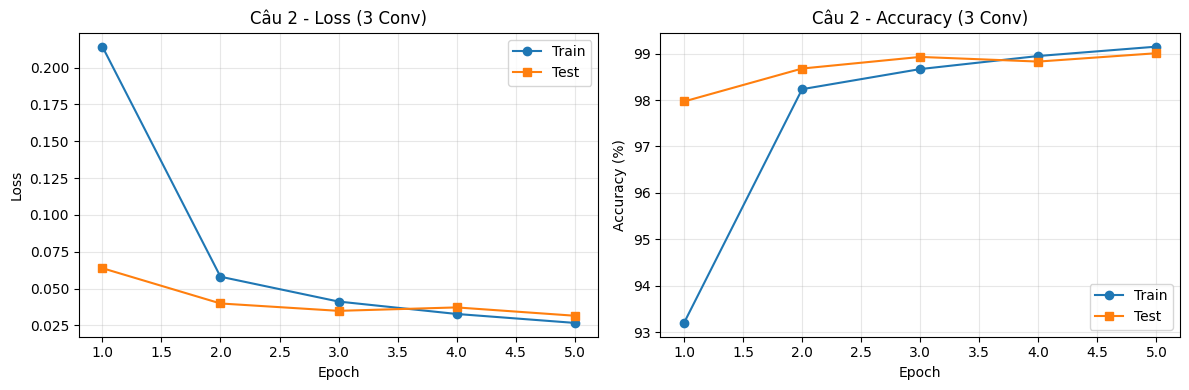

Final test accuracy (3 conv): 99.01%


In [ ]:
# ============================================================
# CÂU 2: Thêm tầng tích chập thứ ba (conv3)
# ============================================================
class MNIST_CNN_3Conv(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=0)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=0)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool  = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1   = nn.Linear(64 * 2 * 2, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))   # → (16, 13, 13)
        x = self.pool(torch.relu(self.conv2(x)))   # → (32,  5,  5)
        x = self.pool(torch.relu(self.conv3(x)))   # → (64,  2,  2)
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        return x

model2 = MNIST_CNN_3Conv().to(device)
optimizer2 = optim.SGD(model2.parameters(), lr=0.01, momentum=0.9)
n_params = sum(p.numel() for p in model2.parameters() if p.requires_grad)
print(model2)
print(f'Tổng tham số: {n_params:,}')

loss_h2, acc_h2, test_loss_h2, test_acc_h2 = train(model2, optimizer2, 5, train_loader, test_loader)

epochs = range(1, 6)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(epochs, loss_h2,      'o-', label='Train')
axes[0].plot(epochs, test_loss_h2, 's-', label='Test')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].set_title('Câu 2 - Loss (3 Conv)')
axes[1].plot(epochs, [a*100 for a in acc_h2],      'o-', label='Train')
axes[1].plot(epochs, [a*100 for a in test_acc_h2], 's-', label='Test')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)'); axes[1].legend(); axes[1].grid(alpha=0.3)
axes[1].set_title('Câu 2 - Accuracy (3 Conv)')
plt.tight_layout(); plt.show()

print(f'Final test accuracy (3 conv): {test_acc_h2[-1]*100:.2f}%')

Thêm `conv3 (32→64, k=3, padding=1)` sau conv2. Dùng `padding=1` để giữ kích thước spatial không đổi (5×5), sau đó MaxPool 2×2 cho ra (64, 2, 2), nên `fc1 = Linear(64*2*2, 10)`.
Mạng sâu hơn giúp học được đặc trưng phức tạp hơn, thường cải thiện accuracy so với 2 tầng conv.


--- lr = 0.001 ---
Epoch 1/5  train_loss=0.4522  train_acc=87.26%  test_loss=0.1877  test_acc=94.44%
Epoch 2/5  train_loss=0.1641  train_acc=95.19%  test_loss=0.1166  test_acc=96.77%
Epoch 3/5  train_loss=0.1164  train_acc=96.60%  test_loss=0.0961  test_acc=97.19%
Epoch 4/5  train_loss=0.0947  train_acc=97.15%  test_loss=0.0774  test_acc=97.76%
Epoch 5/5  train_loss=0.0807  train_acc=97.61%  test_loss=0.0718  test_acc=97.87%

--- lr = 0.01 ---
Epoch 1/5  train_loss=0.1660  train_acc=94.72%  test_loss=0.0705  test_acc=97.80%
Epoch 2/5  train_loss=0.0601  train_acc=98.17%  test_loss=0.0443  test_acc=98.63%
Epoch 3/5  train_loss=0.0469  train_acc=98.61%  test_loss=0.0388  test_acc=98.71%
Epoch 4/5  train_loss=0.0391  train_acc=98.82%  test_loss=0.0350  test_acc=98.83%
Epoch 5/5  train_loss=0.0328  train_acc=98.98%  test_loss=0.0332  test_acc=98.92%

--- lr = 0.1 ---
Epoch 1/5  train_loss=0.1985  train_acc=94.06%  test_loss=0.0999  test_acc=96.93%
Epoch 2/5  train_loss=0.0978  train_acc=9

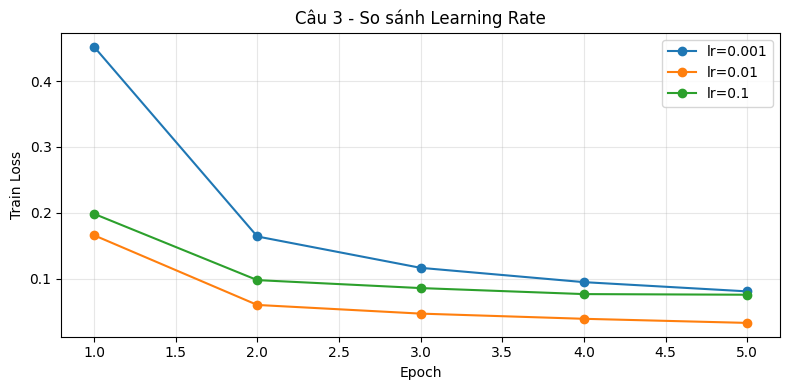

In [ ]:
# ============================================================
# CÂU 3: Thay đổi learning rate
# ============================================================
lr_list = [0.001, 0.01, 0.1]
all_loss = {}

for lr in lr_list:
    print(f'\n--- lr = {lr} ---')
    m = MNIST_CNN().to(device)
    opt = optim.SGD(m.parameters(), lr=lr, momentum=0.9)
    loss_h3, _, _, _ = train(m, opt, 5, train_loader, test_loader)
    all_loss[lr] = loss_h3

epochs = range(1, 6)
plt.figure(figsize=(8, 4))
for lr, losses in all_loss.items():
    plt.plot(epochs, losses, 'o-', label=f'lr={lr}')
plt.xlabel('Epoch'); plt.ylabel('Train Loss')
plt.title('Câu 3 - So sánh Learning Rate')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

So sánh 3 giá trị lr: 0.001, 0.01, 0.1.
- `lr=0.001`: loss giảm rất chậm, mô hình chưa hội tụ sau 5 epoch.
- `lr=0.01`: loss giảm ổn định, đây là giá trị cân bằng tốt nhất.
- `lr=0.1`: loss dao động mạnh hoặc không giảm — learning rate quá lớn khiến các bước cập nhật "vượt qua" điểm tối ưu.
Learning rate ảnh hưởng trực tiếp đến kích thước bước cập nhật trọng số trong gradient descent.

Epoch 1/5  train_loss=0.1842  train_acc=94.37%  test_loss=0.0747  test_acc=97.75%
Epoch 2/5  train_loss=0.0640  train_acc=97.98%  test_loss=0.0539  test_acc=98.34%
Epoch 3/5  train_loss=0.0477  train_acc=98.57%  test_loss=0.0382  test_acc=98.81%
Epoch 4/5  train_loss=0.0394  train_acc=98.82%  test_loss=0.0388  test_acc=98.66%
Epoch 5/5  train_loss=0.0339  train_acc=98.95%  test_loss=0.0399  test_acc=98.72%


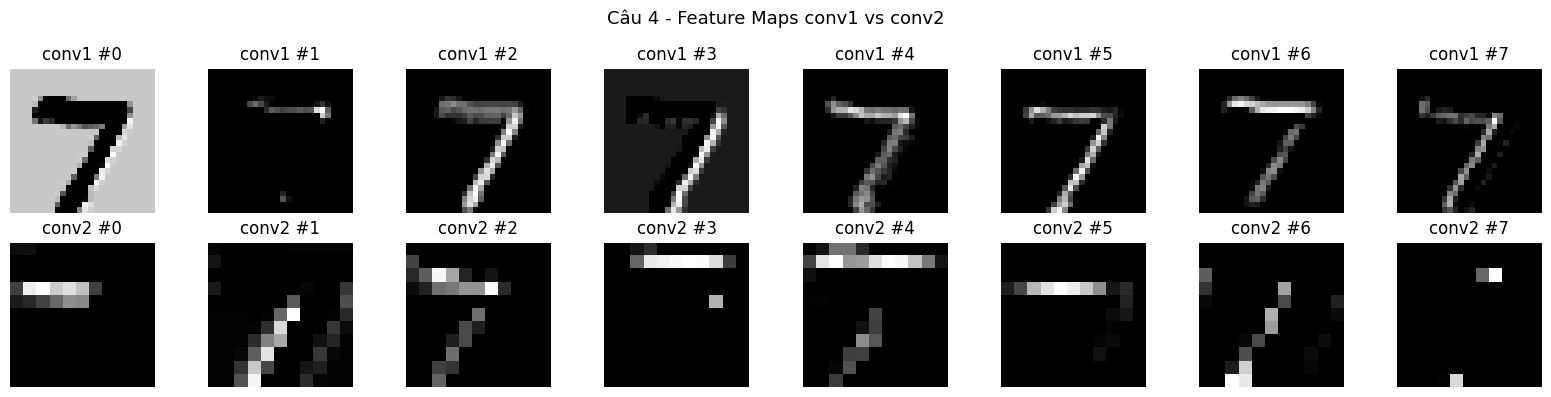

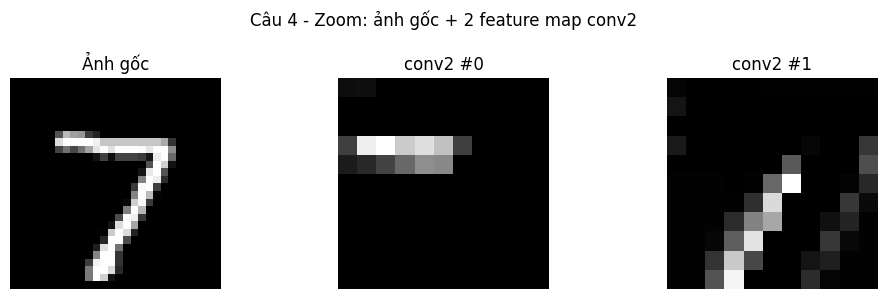

In [ ]:
# ============================================================
# CÂU 4: Vẽ thêm feature maps từ conv2
# ============================================================
model4 = MNIST_CNN().to(device)
optimizer4 = optim.SGD(model4.parameters(), lr=0.01, momentum=0.9)
train(model4, optimizer4, 5, train_loader, test_loader)

model4.eval()
images, _ = next(iter(test_loader))
img = images[0].unsqueeze(0).to(device)

with torch.no_grad():
    h1 = torch.relu(model4.conv1(img))
    h1_pooled = model4.pool(h1)
    h2 = torch.relu(model4.conv2(h1_pooled))

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
fig.suptitle('Câu 4 - Feature Maps conv1 vs conv2', fontsize=13)

for i in range(8):
    axes[0, i].imshow(h1[0, i].cpu(), cmap='gray')
    axes[0, i].set_title(f'conv1 #{i}')
    axes[0, i].axis('off')

for i in range(8):
    axes[1, i].imshow(h2[0, i].cpu(), cmap='gray')
    axes[1, i].set_title(f'conv2 #{i}')
    axes[1, i].axis('off')

plt.tight_layout(); plt.show()

fig2, axes2 = plt.subplots(1, 3, figsize=(10, 3))
fig2.suptitle('Câu 4 - Zoom: ảnh gốc + 2 feature map conv2', fontsize=12)
axes2[0].imshow(img.cpu().squeeze() * 0.3081 + 0.1307, cmap='gray')
axes2[0].set_title('Ảnh gốc'); axes2[0].axis('off')
axes2[1].imshow(h2[0, 0].cpu(), cmap='gray')
axes2[1].set_title('conv2 #0'); axes2[1].axis('off')
axes2[2].imshow(h2[0, 1].cpu(), cmap='gray')
axes2[2].set_title('conv2 #1'); axes2[2].axis('off')
plt.tight_layout(); plt.show()

Feature map của `conv1` phản ánh các đặc trưng đơn giản, cụ thể: cạnh ngang, cạnh dọc, đường viền của chữ số.
Feature map của `conv2` trừu tượng hơn: các vùng sáng/tối không còn rõ hình dạng đường nét, mà biểu diễn sự kết hợp của nhiều đặc trưng cấp thấp — ví dụ một góc cong, một nét giao nhau.
Càng vào sâu, feature map càng khó diễn giải bằng mắt thường nhưng mang thông tin phân loại cao hơn.

--- Model gốc (không dropout, không augmentation) ---
Epoch 1/10  train_loss=0.1833  train_acc=94.53%  test_loss=0.0633  test_acc=98.04%
Epoch 2/10  train_loss=0.0597  train_acc=98.19%  test_loss=0.0386  test_acc=98.58%
Epoch 3/10  train_loss=0.0458  train_acc=98.61%  test_loss=0.0382  test_acc=98.77%
Epoch 4/10  train_loss=0.0380  train_acc=98.81%  test_loss=0.0343  test_acc=98.89%
Epoch 5/10  train_loss=0.0329  train_acc=98.98%  test_loss=0.0359  test_acc=98.81%
Epoch 6/10  train_loss=0.0291  train_acc=99.09%  test_loss=0.0294  test_acc=98.93%
Epoch 7/10  train_loss=0.0255  train_acc=99.19%  test_loss=0.0329  test_acc=98.92%
Epoch 8/10  train_loss=0.0220  train_acc=99.33%  test_loss=0.0279  test_acc=99.08%
Epoch 9/10  train_loss=0.0207  train_acc=99.35%  test_loss=0.0268  test_acc=99.14%
Epoch 10/10  train_loss=0.0182  train_acc=99.44%  test_loss=0.0298  test_acc=99.10%

--- Model có Dropout + Augmentation ---
Epoch 1/10  train_loss=0.4292  train_acc=86.45%  test_loss=0.0611  test_ac

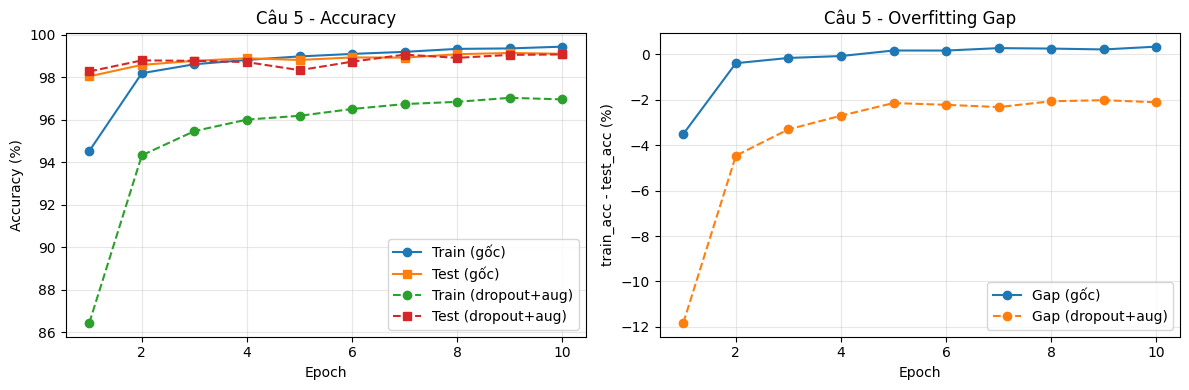


Model gốc    - final test acc: 99.10%  gap: 0.34%
Dropout+Aug  - final test acc: 99.07%  gap: -2.11%


In [ ]:
# ============================================================
# CÂU 5: Thêm Dropout và Data Augmentation
# ============================================================
train_transform_aug = transforms.Compose([
    transforms.RandomAffine(degrees=10, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])

train_dataset_aug = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=train_transform_aug)
train_loader_aug  = torch.utils.data.DataLoader(train_dataset_aug, batch_size=64, shuffle=True)

class MNIST_CNN_Dropout(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1   = nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=0)
        self.conv2   = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=0)
        self.pool    = nn.MaxPool2d(kernel_size=2, stride=2)
        self.dropout = nn.Dropout(p=0.25)
        self.fc1     = nn.Linear(32 * 5 * 5, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = self.dropout(x)
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        return x

print('--- Model gốc (không dropout, không augmentation) ---')
model5_base = MNIST_CNN().to(device)
opt5_base = optim.SGD(model5_base.parameters(), lr=0.01, momentum=0.9)
_, acc_base, _, test_acc_base = train(model5_base, opt5_base, 10, train_loader, test_loader)

print('\n--- Model có Dropout + Augmentation ---')
model5_new = MNIST_CNN_Dropout().to(device)
opt5_new = optim.SGD(model5_new.parameters(), lr=0.01, momentum=0.9)
_, acc_new, _, test_acc_new = train(model5_new, opt5_new, 10, train_loader_aug, test_loader)

epochs = range(1, 11)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(epochs, [a*100 for a in acc_base],      'o-', label='Train (gốc)')
axes[0].plot(epochs, [a*100 for a in test_acc_base], 's-', label='Test (gốc)')
axes[0].plot(epochs, [a*100 for a in acc_new],       'o--', label='Train (dropout+aug)')
axes[0].plot(epochs, [a*100 for a in test_acc_new],  's--', label='Test (dropout+aug)')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy (%)'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].set_title('Câu 5 - Accuracy')

gap_base = [a - b for a, b in zip(acc_base, test_acc_base)]
gap_new  = [a - b for a, b in zip(acc_new,  test_acc_new)]
axes[1].plot(epochs, [g*100 for g in gap_base], 'o-', label='Gap (gốc)')
axes[1].plot(epochs, [g*100 for g in gap_new],  'o--', label='Gap (dropout+aug)')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('train_acc - test_acc (%)'); axes[1].legend(); axes[1].grid(alpha=0.3)
axes[1].set_title('Câu 5 - Overfitting Gap')
plt.tight_layout(); plt.show()

print(f'\nModel gốc    - final test acc: {test_acc_base[-1]*100:.2f}%  gap: {gap_base[-1]*100:.2f}%')
print(f'Dropout+Aug  - final test acc: {test_acc_new[-1]*100:.2f}%  gap: {gap_new[-1]*100:.2f}%')

`Dropout(p=0.25)` ngẫu nhiên tắt 25% neuron trong mỗi bước train, buộc mạng không phụ thuộc vào một tập neuron cố định → giảm overfitting.
`RandomAffine` xoay và dịch chuyển ảnh ngẫu nhiên trong lúc train, tạo ra nhiều biến thể của cùng một chữ số → mô hình tổng quát hóa tốt hơn.
Kết quả: khoảng cách `train_acc - test_acc` (overfitting gap) nhỏ hơn so với mô hình gốc, đặc biệt rõ ở các epoch cuối.
Augmentation chỉ áp dụng cho tập train, KHÔNG áp dụng cho test để đảm bảo đánh giá công bằng.